# GlucoLens: Explainable ML for Early Prediction of Diabetes Risk

1. **Classification:** does a patient have diabetes? (Pima Indians Diabetes data)
2. **Regression:** how much will the disease progress in one year? (Diabetes Progression data)

| # | Rubric item | Marks | Section |
|---|---|---|---|
| 1 | Problem Understanding & Familiarization | 4 | A |
| 2 | Exploratory Data Analysis & Insights | 4 | B |
| 3 | Regression and Classification | 4 | C, D, E |
| 4 | Comparative Performance Analysis | 4 | F |
| 5 | Result Interpretation & Presentation | 4 | G, H |

## Setup
Import libraries, set one random seed for the whole notebook (so results are the same every run), and create folders for data and figures.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml, load_diabetes

RANDOM_STATE = 42  # used everywhere so results are reproducible

os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# Section A: Problem Understanding *(Rubric 1)*

## A.1 Background
- **Diabetes:** blood glucose stays too high because the body makes too little **insulin** or does not respond to it.
- **Type 1:** the body makes almost no insulin (autoimmune, usually starts young). **Type 2:** the body resists insulin; linked to obesity, inactivity and age. Most cases, and both our adult datasets, are Type 2.
- **Why early detection:** Type 2 can go unnoticed for years while damaging eyes, kidneys, nerves and heart. Catching it early lets lifestyle changes or treatment delay it.
- **Known risk factors:** high glucose, high BMI, older age, family history, high blood pressure.
- **Why explainability:** doctors must be able to see *why* a model flags a patient, to trust it, justify decisions and spot when the model is using a wrong signal.

## A.2 The two tasks

| | Classification | Regression |
|---|---|---|
| Data | Pima (768 patients, 8 features) | Progression (442 patients, 10 features) |
| Target | `Outcome`: 1 = diabetic, 0 = not | `target`: progression score after 1 year |
| Why this type | Target has only 2 values | Target is a continuous number |

- A classifier predicts a probability $\hat{p} = P(y=1 \mid \mathbf{x})$ and says "diabetic" if $\hat{p} \ge 0.5$ (we can change this threshold later).
- A regressor predicts a number $\hat{y} = f(\mathbf{x})$.

Here $\mathbf{x}$ = a patient's features, $y$ = the true target, $\hat{y}$ = the prediction.

## A.3 Feature dictionary

**Pima** (women aged 21+, Pima Indian heritage, Arizona)

| Feature | Unit | Meaning | Modifiable? |
|---|---|---|---|
| Pregnancies | count | Number of pregnancies | No |
| Glucose | mg/dL | Blood glucose 2 h after a sugar drink (glucose tolerance test) | Yes |
| BloodPressure | mm Hg | Diastolic blood pressure | Yes |
| SkinThickness | mm | Triceps skin-fold thickness (body fat) | Yes |
| Insulin | µU/mL | Blood insulin 2 h after the sugar drink | Partly |
| BMI | kg/m² | Weight / height² | Yes |
| DiabetesPedigreeFunction | score | Diabetes history in relatives (genetic risk) | No |
| Age | years | Age | No |
| **Outcome** | 0/1 | 1 = diabetic | target |

**Progression** (names as in scikit-learn)

| Feature | Meaning | Modifiable? |
|---|---|---|
| age | Age (years) | No |
| sex | Coded 1 or 2 (source does not say which is which) | No |
| bmi | Body mass index (kg/m²) | Yes |
| bp | Average blood pressure (mm Hg) | Yes |
| s1 | Total cholesterol | Yes |
| s2 | LDL ("bad" cholesterol) | Yes |
| s3 | HDL ("good" cholesterol) | Yes |
| s4 | Total cholesterol / HDL | Yes |
| s5 | Probably log of triglycerides | Yes |
| s6 | Blood sugar | Yes |
| **target** | Disease progression after 1 year (score) | target |

## A.4 Success criteria (set before seeing any results)

**Classification** (on the test set)
- **Recall ≥ 0.75**: catch at least 3 of every 4 diabetic patients. Missing a diabetic (false negative) is worse than a false alarm.
- **ROC-AUC ≥ 0.80**: the model ranks diabetic patients above non-diabetic ones well.

$$\text{Recall} = \frac{TP}{TP + FN}$$
($TP$ = diabetics correctly flagged, $FN$ = diabetics missed)

**Regression** (on the test set)
- Clearly beat a model that always predicts the mean (which has $R^2 = 0$); aim for **$R^2 \ge 0.40$**.

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$
($y_i$ = true value, $\hat{y}_i$ = prediction, $\bar{y}$ = mean of true values)

## A.5 Load the data

**Pima:** download from OpenML the first time, rename the short column names (`preg`, `plas`, ...) to clear names, turn the text label into 1/0, and save to `data/pima.csv`. Later runs just read the CSV (works offline).

In [2]:
if os.path.exists("data/pima.csv"):
    pima = pd.read_csv("data/pima.csv")
else:
    pima = fetch_openml(name="diabetes", version=1, as_frame=True).frame
    pima.columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
    # label is text: "tested_positive" -> 1, "tested_negative" -> 0
    pima["Outcome"] = (pima["Outcome"] == "tested_positive").astype(int)
    pima.to_csv("data/pima.csv", index=False)

print("Pima shape:", pima.shape)
pima.head()

Pima shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Progression:** comes with scikit-learn. `scaled=False` keeps the real units (age in years, BMI in kg/m²) instead of pre-scaled numbers. Saved to `data/progression.csv`.

In [3]:
if os.path.exists("data/progression.csv"):
    prog = pd.read_csv("data/progression.csv")
else:
    prog = load_diabetes(as_frame=True, scaled=False).frame
    prog.to_csv("data/progression.csv", index=False)

print("Progression shape:", prog.shape)
prog.head()

Progression shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


**Observation:** Pima has **768 rows × 9 columns** (8 features + `Outcome`) and Progression has **442 rows × 11 columns** (10 features + `target`). Already in the first five Pima rows, `Insulin` is 0 for three patients and `SkinThickness` is 0 for one. These values are impossible, so they must be missing. The Progression values are in real units (e.g. age 59, BMI 32.1), so `scaled=False` worked.

## A.6 Data types and summary statistics

`.info()` shows each column's type and how many values are not missing. `.describe()` shows count, mean, standard deviation, min, quartiles (25%, 50% = **median**, 75%) and max.

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i \qquad s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$
($n$ = number of values, $\bar{x}$ = mean, $s$ = standard deviation)

In [4]:
pima.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
pima.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


**Observation:** `.info()` says all 768 values are present in every column, but `.describe()` shows a **minimum of 0** for Glucose, BloodPressure, SkinThickness, Insulin and BMI, which is impossible. The missing values are hidden as zeros. For SkinThickness and Insulin even the 25th percentile is 0, so at least a quarter of those values are missing. The mean of `Outcome` is 0.35, so about **35% of patients are diabetic**.

In [6]:
prog.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [7]:
prog.describe().round(2)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00
mean,48.52,1.47,26.38,94.65,189.14,115.44,49.79,4.07,4.64,91.26,152.13
std,13.11,0.50,4.42,13.83,34.61,30.41,12.93,1.29,0.52,11.50,77.09
min,19.00,1.00,18.00,62.00,97.00,41.60,22.00,2.00,3.26,58.00,25.00
25%,38.25,1.00,23.20,84.00,164.25,96.05,40.25,3.00,4.28,83.25,87.00
50%,50.00,1.00,25.70,93.00,186.00,113.00,48.00,4.00,4.62,91.00,140.50
75%,59.00,2.00,29.28,105.00,209.75,134.50,57.75,5.00,5.00,98.00,211.50
max,79.00,2.00,42.20,133.00,301.00,242.40,99.00,9.09,6.11,124.00,346.00


**Observation:** There are no missing values (442 non-null in every column) and no impossible values. The `target` ranges from **25 to 346** (mean 152.13, std 77.09). The features are on very different scales (`s5` is around 4.6 while `s1` is around 189), so models based on distances or coefficients will need **scaling** (Section C).

## A.7 Limitations
- Pima has only adult women of one ethnic group, so results may not apply to others.
- Both datasets are small, so scores will vary between splits (we report cross-validation mean ± std).
- Diabetes is diagnosed from glucose, so a strong glucose effect is partly built into the label.
- Models find correlations, not causes. This is a course prototype, not a diagnostic tool.

# Section B: Exploratory Data Analysis *(Rubric 2)*

## B.1 Pima: hidden missing values

A value of `0` for Glucose, BloodPressure, SkinThickness, Insulin or BMI is impossible for a living person, so it means "not recorded". We count these zeros.

               zeros  percent
Glucose            5      0.7
BloodPressure     35      4.6
SkinThickness    227     29.6
Insulin          374     48.7
BMI               11      1.4


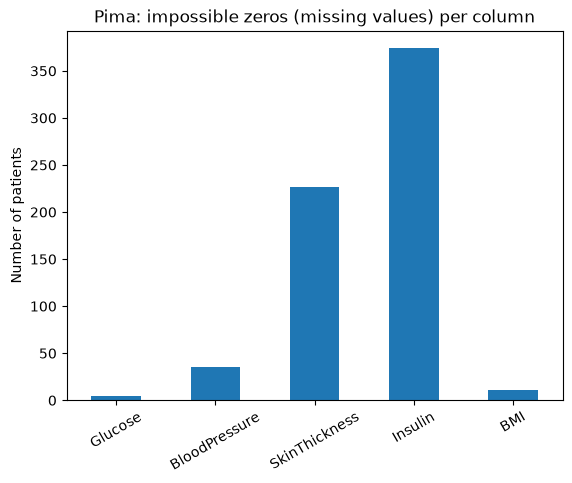

In [8]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = (pima[zero_cols] == 0).sum()
zero_percent = (zero_counts / len(pima) * 100).round(1)
print(pd.DataFrame({"zeros": zero_counts, "percent": zero_percent}))

zero_counts.plot(kind="bar", color="tab:blue")
plt.title("Pima: impossible zeros (missing values) per column")
plt.ylabel("Number of patients")
plt.xticks(rotation=30)
plt.savefig("figures/fig01_pima_missing_zeros.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Missing values are concentrated in **Insulin (374 patients, 48.7%)** and **SkinThickness (227, 29.6%)**. BloodPressure (35), BMI (11) and Glucose (5) have only a few. If we treated these zeros as real numbers, they would drag the averages down and mislead the models, so we fill them with the median in Section C. Because almost half of the Insulin values will be filled in, any result involving Insulin should be read with caution.

We now replace these zeros with `NaN` (pandas' "missing" value), so the plots below show only real measurements.
This learns nothing from the data, so it causes no leakage. The missing values are **filled in later (Section C)** with the median of the training set only.

In [9]:
pima[zero_cols] = pima[zero_cols].replace(0, np.nan)
pima.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

## B.2 Pima: class balance
How many patients are diabetic vs not?

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


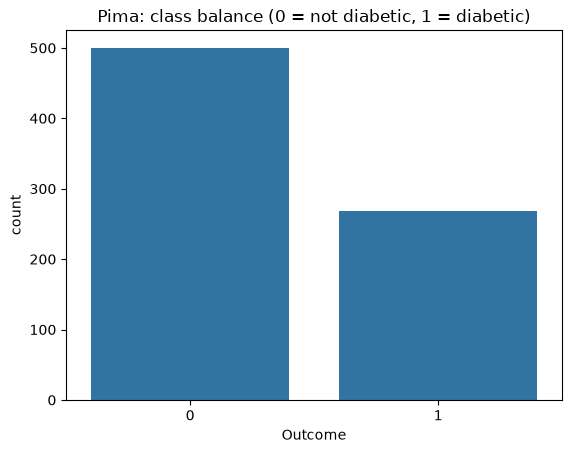

In [10]:
print(pima["Outcome"].value_counts())
print((pima["Outcome"].value_counts(normalize=True) * 100).round(1))

sns.countplot(x="Outcome", data=pima, color="tab:blue")
plt.title("Pima: class balance (0 = not diabetic, 1 = diabetic)")
plt.savefig("figures/fig02_pima_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** There are **500 non-diabetic (65.1%)** and **268 diabetic (34.9%)** patients. A useless model that always says "not diabetic" would already reach 65.1% accuracy, so accuracy is misleading here. This is why we use a stratified split, `class_weight="balanced"`, and recall as the main metric.

## B.3 Pima: feature distributions by Outcome
Histograms of each feature, coloured by class. Each class is scaled to the same area (`stat="density"`), because there are fewer diabetics and we want to compare **shapes**, not counts. If the two colours are shifted apart, that feature helps separate the classes.

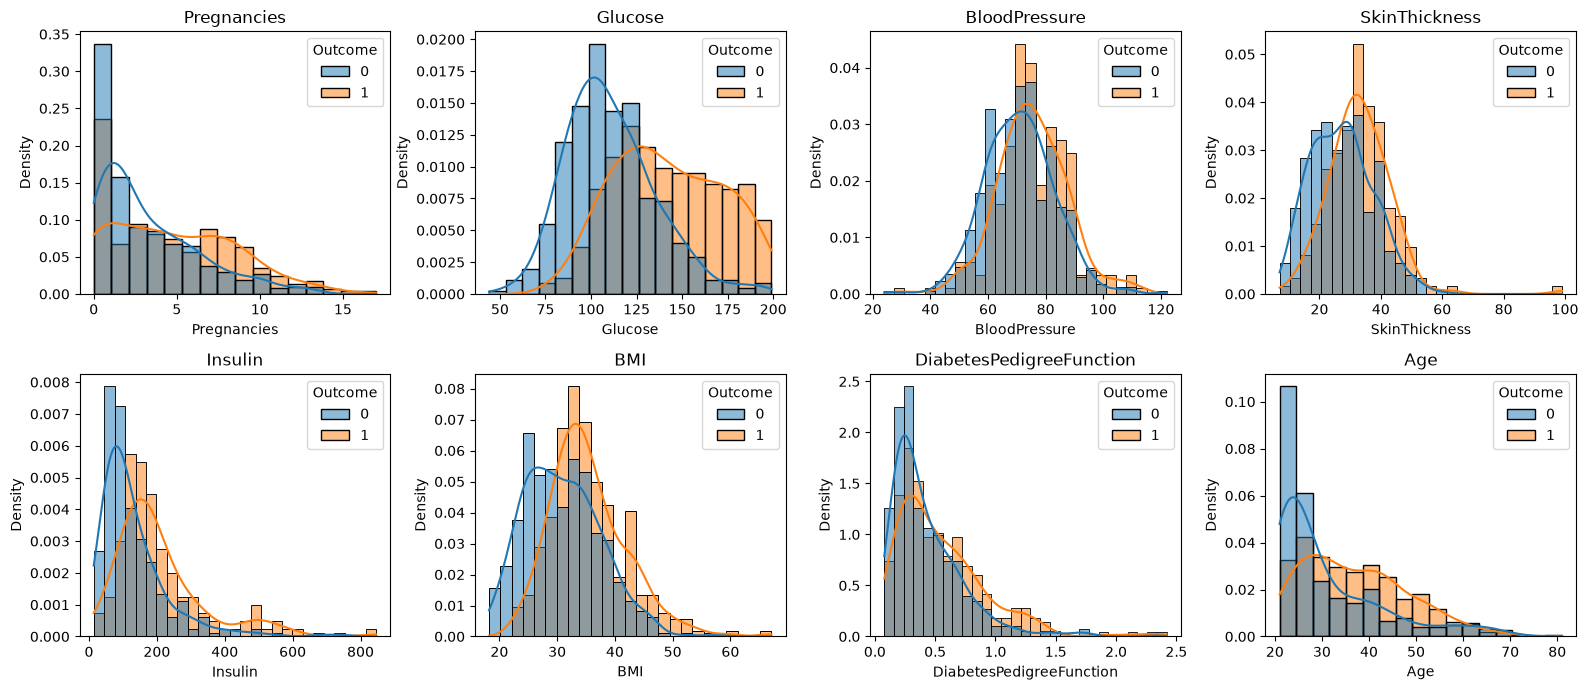

In [11]:
features = pima.columns.drop("Outcome")

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), features):   # one small plot per feature
    sns.histplot(data=pima, x=col, hue="Outcome", kde=True, ax=ax,
                 stat="density", common_norm=False,  # compare shapes, not counts
                 palette=["tab:blue", "tab:orange"])
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/fig03_pima_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

To put numbers on the histograms, we compare the **median** of each feature in the two classes.

In [12]:
pima.groupby("Outcome").median().T

Outcome,0,1
Pregnancies,2.000,4.000
Glucose,107.000,140.000
BloodPressure,70.000,74.500
SkinThickness,27.000,32.000
Insulin,102.500,169.500
BMI,30.100,34.300
DiabetesPedigreeFunction,0.336,0.449
Age,27.000,36.000


**Observation:** **Glucose** shows the clearest shift: the median is 107 for non-diabetics and 140 for diabetics, and the diabetic curve sits clearly to the right. Diabetics also have higher medians for BMI (34.3 vs 30.1), Age (36 vs 27), Insulin (169.5 vs 102.5) and Pregnancies (4 vs 2). BloodPressure (74.5 vs 70) and DiabetesPedigreeFunction (0.449 vs 0.336) differ less, and their curves overlap a lot. Insulin, DiabetesPedigreeFunction, Age and Pregnancies are **right-skewed**: most values are small, with a long tail of large values.

## B.4 Pima: outliers

A box plot shows the median (middle line), the quartiles $Q_1$ and $Q_3$ (box edges) and dots for outliers. We use the **IQR rule**:

$$IQR = Q_3 - Q_1 \qquad \text{outlier if } x < Q_1 - 1.5\,IQR \ \text{ or } \ x > Q_3 + 1.5\,IQR$$

The small function below counts outliers per column with this rule. We use it for both datasets, so we write it once.

In [13]:
def count_outliers(df, columns):
    rows = []
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        n = ((df[col] < lower) | (df[col] > upper)).sum()
        rows.append([col, lower, upper, n])
    return pd.DataFrame(rows, columns=["feature", "lower", "upper", "n_outliers"])

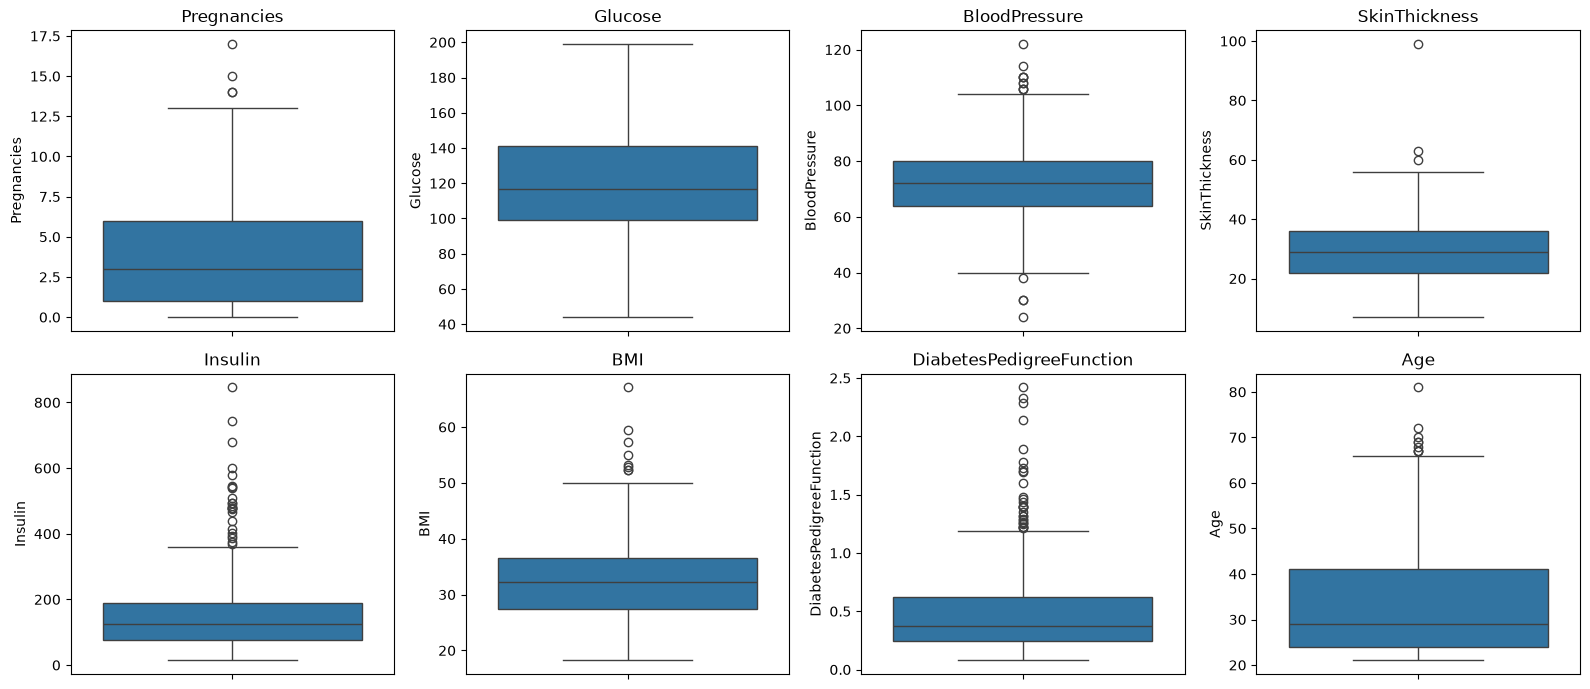

,feature,lower,upper,n_outliers
0,Pregnancies,-6.50,13.50,4
1,Glucose,36.00,204.00,0
2,BloodPressure,40.00,104.00,14
3,SkinThickness,1.00,57.00,3
4,Insulin,-94.38,360.62,24
5,BMI,13.85,50.25,8
6,DiabetesPedigreeFunction,-0.33,1.20,29
7,Age,-1.50,66.50,9


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(y=pima[col], ax=ax, color="tab:blue")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/fig04_pima_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

count_outliers(pima, features).round(2)

**Observation:** The IQR rule flags the most outliers in DiabetesPedigreeFunction (29), Insulin (24) and BloodPressure (14), and **none in Glucose**. These look like real but extreme patients (for example, a few very high insulin readings), not data errors, so we **keep them**. Removing real patients would throw away information from an already small dataset.

## B.5 Pima: correlation

**Pearson correlation** $r$ measures how strongly two features rise or fall together in a straight line, from −1 to +1 (0 = no linear relation):

$$r = \frac{\text{cov}(X, Y)}{\sigma_X \, \sigma_Y}$$
($\text{cov}$ = covariance, $\sigma$ = standard deviation). Missing values are skipped pair by pair.

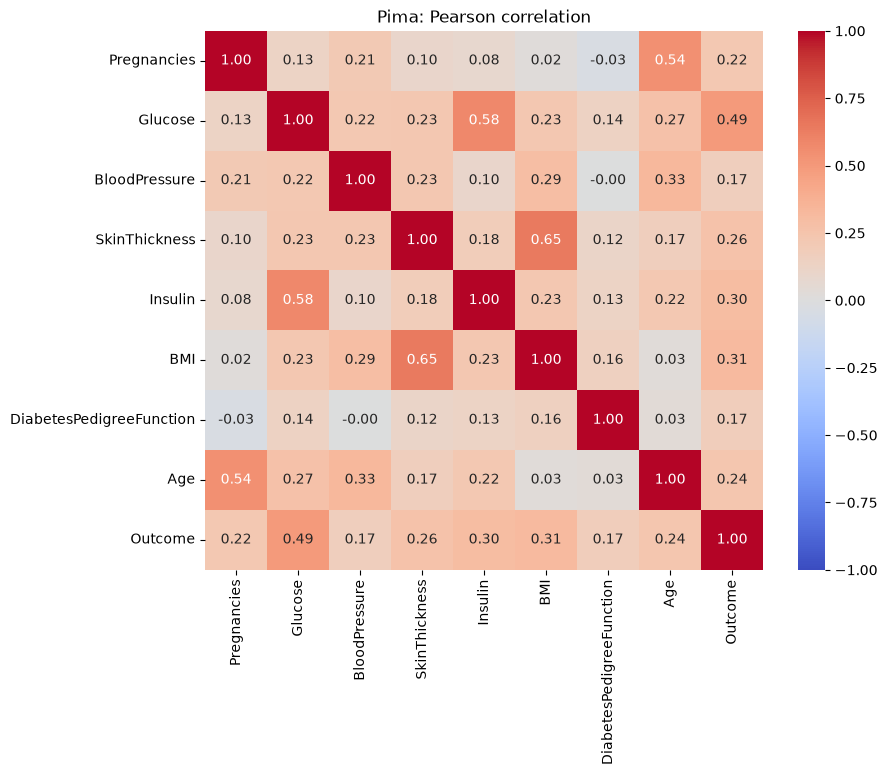

Glucose                     0.494650
BMI                         0.313680
Insulin                     0.303454
SkinThickness               0.259491
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
BloodPressure               0.170589
Name: Outcome, dtype: float64

In [15]:
pima_corr = pima.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(pima_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pima: Pearson correlation")
plt.savefig("figures/fig05_pima_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# correlation of each feature with the target, strongest first
pima_corr["Outcome"].drop("Outcome").sort_values(ascending=False)

**Observation:** **Glucose has the strongest correlation with Outcome (0.49)**, followed by BMI (0.31) and Insulin (0.30). BloodPressure and DiabetesPedigreeFunction are the weakest (0.17 each). Among the features themselves, the strongest pairs make clinical sense: SkinThickness–BMI (0.65, both measure body fat), Glucose–Insulin (0.58, the body releases insulin in response to glucose) and Age–Pregnancies (0.54). No pair is extremely high, so no feature is a near-duplicate of another.

## B.6 Pima: strongest relationships
Box plots of the three features most correlated with `Outcome`.

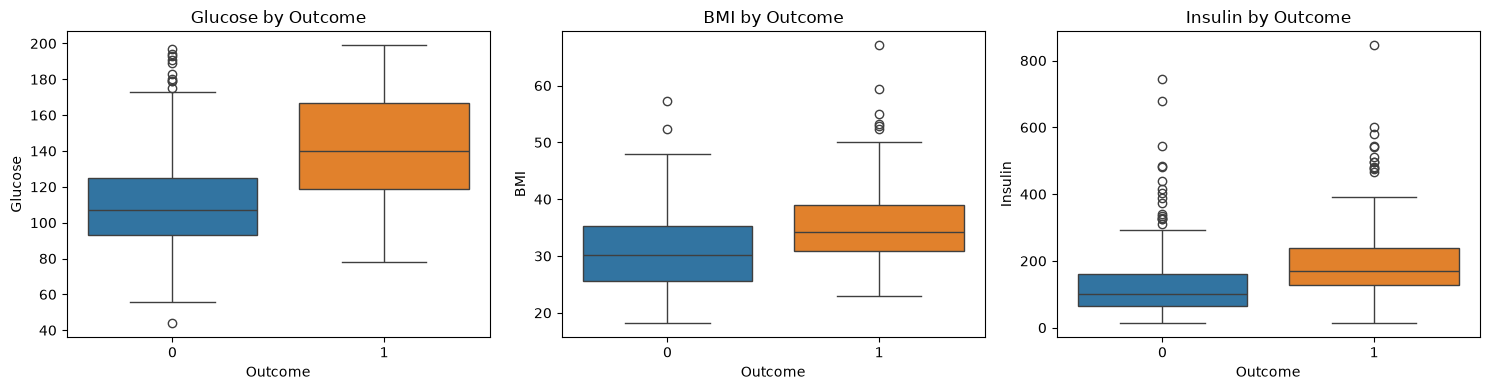

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Glucose", "BMI", "Insulin"]):
    sns.boxplot(data=pima, x="Outcome", y=col, ax=ax, hue="Outcome",
                palette=["tab:blue", "tab:orange"], legend=False)
    ax.set_title(col + " by Outcome")
plt.tight_layout()
plt.savefig("figures/fig06_pima_top_features.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** For all three features, the diabetic box (orange) sits higher. The gap is clearest for **Glucose**: the boxes holding the middle 50% of each class barely overlap. BMI and Insulin are higher for diabetics too, but their boxes overlap much more, so on their own they separate the classes less well.

## B.7 Progression: missing values and target distribution

Missing values in the whole table: 0


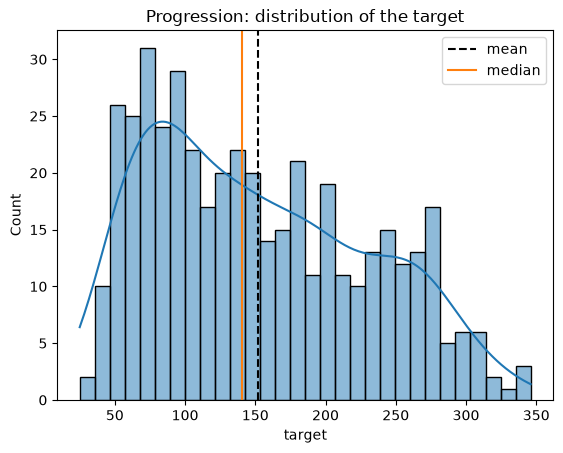

In [17]:
print("Missing values in the whole table:", prog.isnull().sum().sum())

sns.histplot(prog["target"], bins=30, kde=True, color="tab:blue")
plt.axvline(prog["target"].mean(), color="black", linestyle="--", label="mean")
plt.axvline(prog["target"].median(), color="tab:orange", label="median")
plt.legend()
plt.title("Progression: distribution of the target")
plt.savefig("figures/fig07_prog_target.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** There are **no missing values** in the progression data. The target is spread widely, from 25 to 346. The median (140.5) is lower than the mean (152.13), so the distribution is slightly right-skewed: more patients have low progression, with a tail of high values. The skew is mild, so we keep the target as it is.

## B.8 Progression: feature distributions

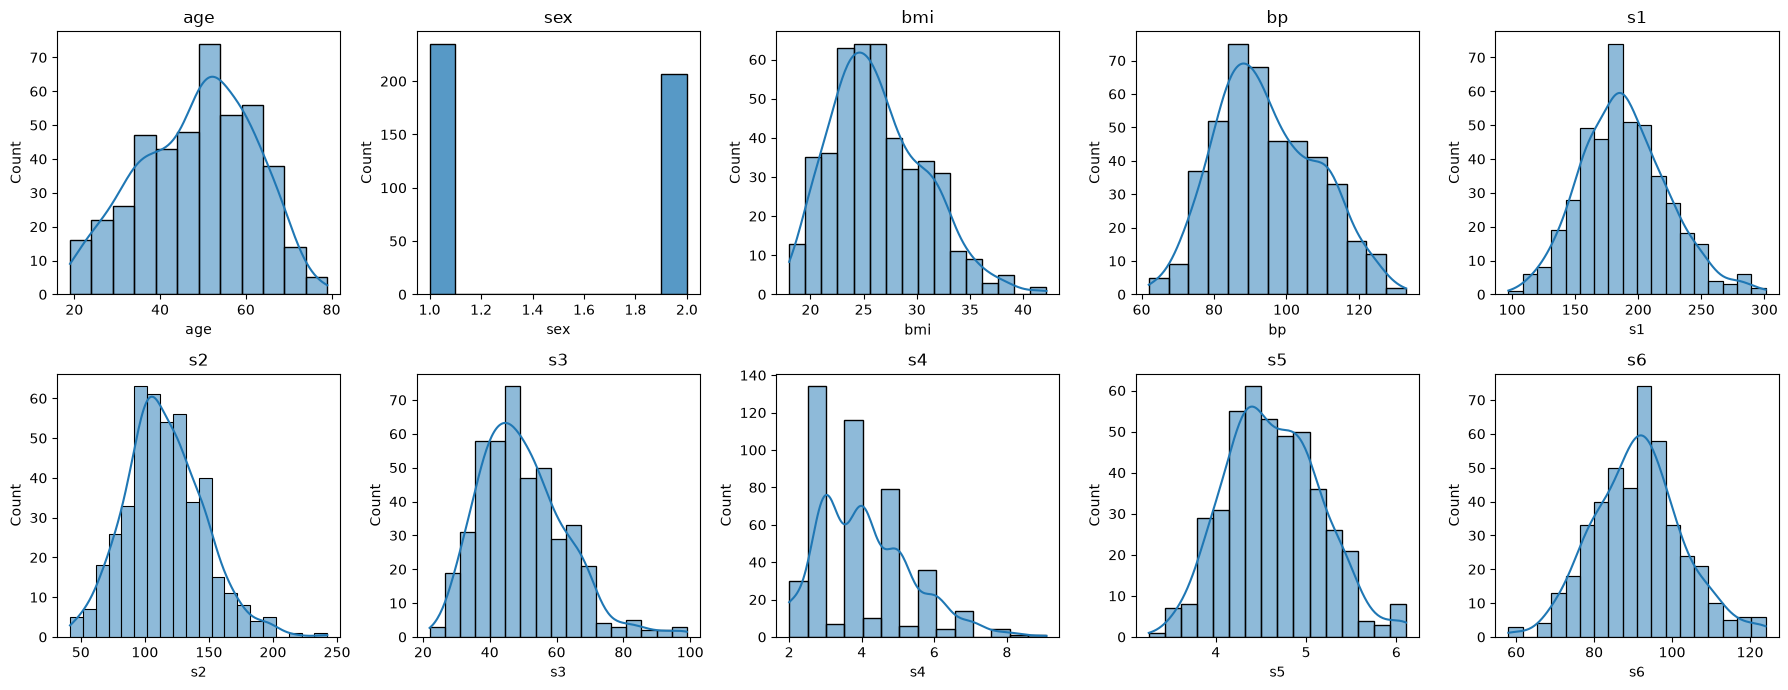

In [18]:
prog_features = prog.columns.drop("target")

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flatten(), prog_features):
    # sex only has two values (1, 2), so a smooth KDE curve makes no sense there
    sns.histplot(prog[col], kde=(col != "sex"), ax=ax, color="tab:blue")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/fig08_prog_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Most features are roughly bell-shaped, and `bmi` is slightly right-skewed. `sex` has only two values (235 patients coded 1, 207 coded 2). `s4` (total cholesterol / HDL) mostly takes whole numbers (3, 4, 5), which suggests it was rounded when recorded.

## B.9 Progression: outliers (same IQR rule)

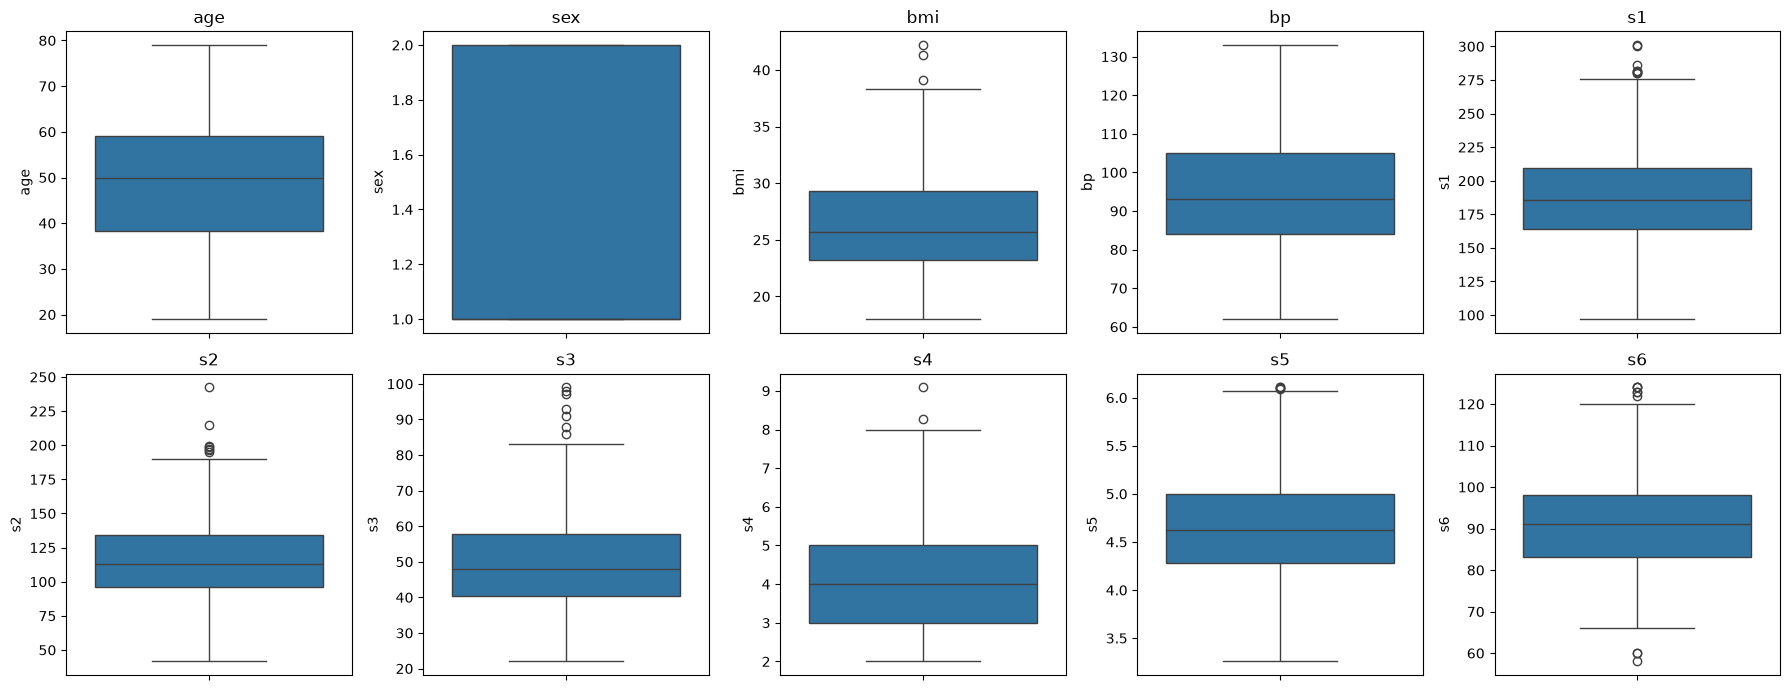

,feature,lower,upper,n_outliers
0,age,7.12,90.12,0
1,sex,-0.50,3.50,0
2,bmi,14.09,38.39,3
3,bp,52.50,136.50,0
4,s1,96.00,278.00,8
5,s2,38.37,192.18,7
6,s3,14.00,84.00,7
7,s4,0.00,8.00,2
8,s5,3.20,6.08,4
9,s6,61.12,120.12,9


In [19]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flatten(), prog_features):
    sns.boxplot(y=prog[col], ax=ax, color="tab:blue")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/fig09_prog_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

count_outliers(prog, prog_features).round(2)

**Observation:** There are very few outliers: at most 9 in a column (`s6`), and none in `age`, `sex` or `bp`. With so few, and all of them plausible, we keep every patient.

## B.10 Progression: correlation (same Pearson formula)

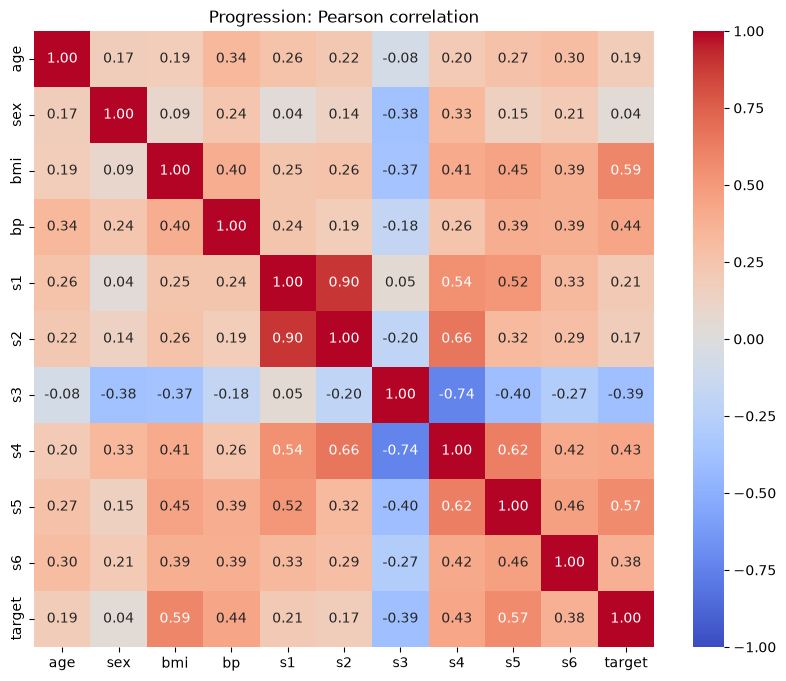

bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64

In [20]:
prog_corr = prog.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(prog_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Progression: Pearson correlation")
plt.savefig("figures/fig10_prog_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

prog_corr["target"].drop("target").sort_values(ascending=False)

**Observation:** The features most correlated with progression are **bmi (0.59)** and **s5 (0.57, triglycerides)**, then bp (0.44) and s4 (0.43). **s3 (HDL, "good" cholesterol) is negative (−0.39)**: more HDL goes with less progression, which matches medicine. `sex` is almost unrelated (0.04). Two feature pairs are strongly correlated: **s1–s2 (0.90)** and s3–s4 (−0.74). This matters for Linear Regression, where such pairs make coefficients unstable, and is one reason we also try Ridge and Lasso.

## B.11 Progression: strongest relationships
Scatter plots of the two features most correlated with the target, with a straight-line fit.

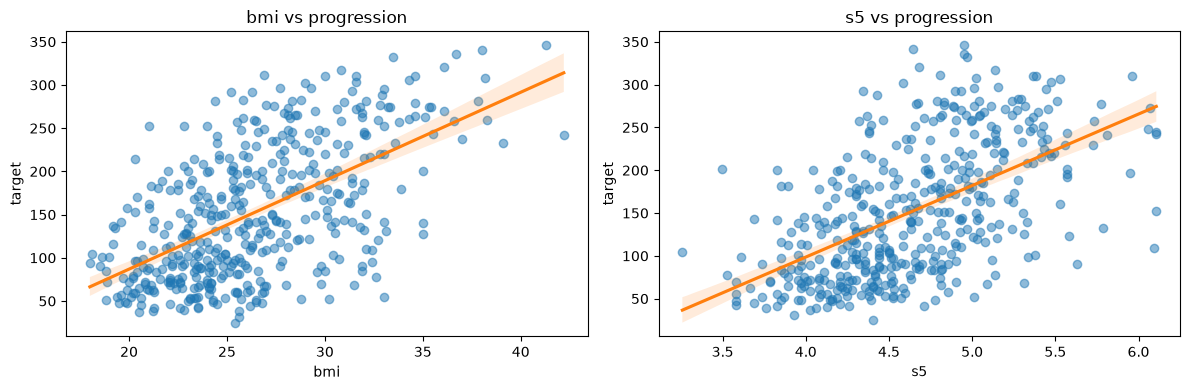

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["bmi", "s5"]):
    sns.regplot(data=prog, x=col, y="target", ax=ax,
                scatter_kws={"alpha": 0.5}, line_kws={"color": "tab:orange"})
    ax.set_title(col + " vs progression")
plt.tight_layout()
plt.savefig("figures/fig11_prog_top_features.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Both scatter plots show a clear upward trend: patients with higher BMI or higher s5 tend to progress more. The points are widely scattered around the line, though, so one feature alone cannot predict progression accurately. We will need to combine several features, and we should expect a moderate R², not a near-perfect one.

## Key EDA Insights
1. **Glucose is the strongest signal for diabetes** (correlation 0.49 with Outcome; median 140 vs 107). This matches medicine, since diabetes is diagnosed from glucose, so we expect Glucose to be the top feature in every model and in SHAP (Section G).
2. **Pima has many hidden missing values**, especially Insulin (48.7%) and SkinThickness (29.6%). We converted the zeros to NaN and will fill them with the **training-set median inside a Pipeline** (Section C), to avoid leakage. The median is used because these columns are skewed.
3. **The classes are imbalanced (65.1% vs 34.9%)**, so accuracy is misleading. We will use a stratified split, `class_weight="balanced"`, and recall + ROC-AUC.
4. **BMI and body fat matter in both datasets**: BMI is the 2nd-strongest feature for diabetes (0.31) and the strongest for progression (0.59). BMI is *modifiable*, so it is the most useful finding for prevention advice.
5. **Features are on very different scales** (e.g. Insulin up to 846 vs DiabetesPedigreeFunction below 2.5; s1 around 189 vs s5 around 4.6). Distance- and coefficient-based models (Linear/Ridge/Lasso, Logistic Regression, KNN, SVM) need **StandardScaler**; tree models do not.
6. **Outliers are few and look like real patients**, so we keep them all. Tree-based models are hardly affected by extreme values, which is one reason to include them.
7. **Strongly correlated features in Progression (s1–s2: 0.90)** will make plain Linear Regression coefficients unstable. Ridge and Lasso should handle this, and Lasso may drop one of the pair (Section D).